# 0) Objectif de la 1ère approche (données uniquement)

## 0.1) Contexte
On dispose d’une série historique (149 ans) de **maxima annuels de crues**.  
Chaque année t est associée à :
- un **débit maximal annuel** noté Q (en m³/s),
- une **hauteur maximale associée** notée H (en m), avec certaines valeurs manquantes.

Dans cette **première approche**, on dimensionne la digue **uniquement à partir des observations historiques**, sans utiliser de modèle hydraulique (équations) ni de modèle économique.  
L’objectif est de proposer une hauteur de digue hd pour laquelle la **surverse** (dépassement de la digue) soit **rare**.

Ici la **variable cible est H**

- traite des **valeurs manquantes** : l’analyse est réalisée sur les années où H est disponible,


Cette étape fournit une série de maxima annuels propre, utilisée ensuite par les trois routes :
1) quantile empirique,  
2) quantile sûr de Wilks,  
3) EVT (Gumbel / GEV).

## 0.2 Imports librairies et chargement dataset

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Charger dataset

In [2]:
df_rivieres = pd.read_excel(
    "Données-Projet-Pratique-Fiabilité-ISUP-SCDI_E-Remy _2025-2026.xlsx",
    sheet_name="Données débit-hauteur"
)

# Renommer les colonnes (proprement)
df_rivieres = df_rivieres.rename(columns={
    "Débit mesuré maximal annuel (en m3/s)": "Debit",
    "Hauteur associée mesurée (en m)": "Hauteur",
    "Année": "Annee"
})

df_rivieres.head()

,Annee,Debit,Hauteur
0,1849,3853.892756,NaN
1,1850,1256.402143,4.0
2,1851,1648.542191,4.5
3,1852,1604.857094,4.3
4,1853,341.157419,1.7


## 0.3) Exploration rapide des données

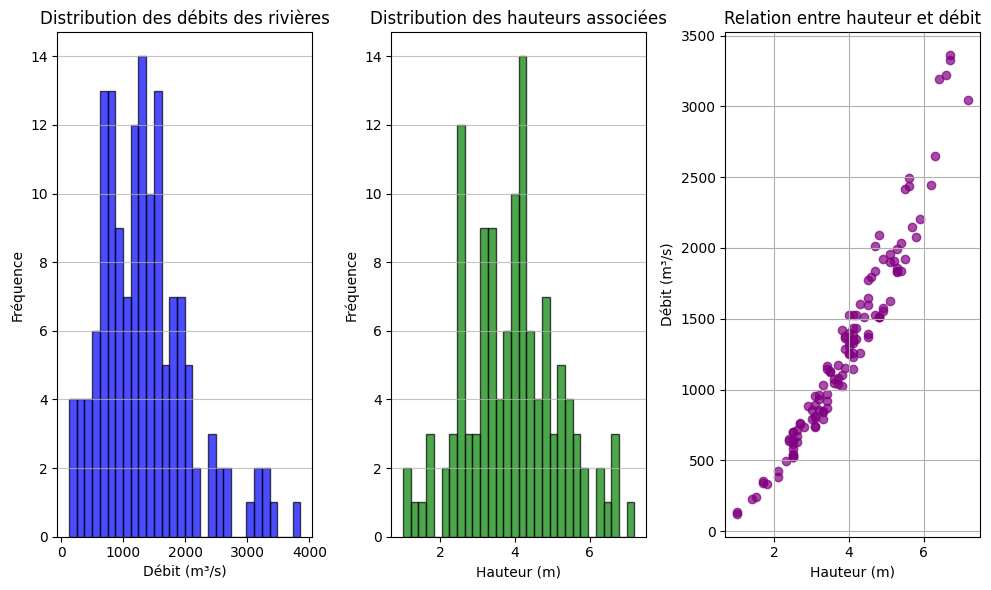

In [13]:
# Affichage de la distribution des données dans un seul graphique

plt.figure(figsize=(10, 6))
plt.subplot(1, 3, 1)

plt.hist(df_rivieres['Debit'], bins=30, alpha=0.7
            , color='blue', edgecolor='black')
plt.title('Distribution des débits des rivières')
plt.xlabel('Débit (m³/s)')
plt.ylabel('Fréquence')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 3, 2)
plt.hist(df_rivieres['Hauteur'], bins=30, alpha=0.7
            , color='green', edgecolor='black')
plt.title('Distribution des hauteurs associées')
plt.xlabel('Hauteur (m)')
plt.ylabel('Fréquence')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 3, 3)
plt.scatter(df_rivieres['Hauteur'], df_rivieres['Debit'], alpha=
            0.7, color='purple')
plt.title('Relation entre hauteur et débit')
plt.xlabel('Hauteur (m)')
plt.ylabel('Débit (m³/s)')
plt.grid()

plt.tight_layout()
plt.show()


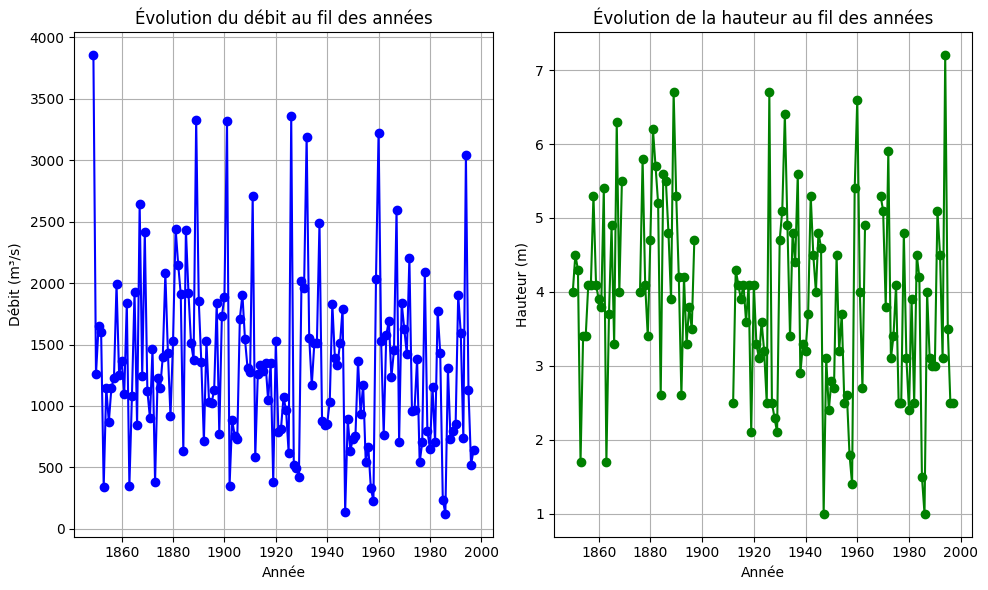

In [15]:
# Il y a t'il une evolution dans le temps ?
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(df_rivieres['Annee'], df_rivieres['Debit'], marker='o', linestyle='-', color='blue')
plt.title('Évolution du débit au fil des années')
plt.xlabel('Année')
plt.ylabel('Débit (m³/s)')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(df_rivieres['Annee'], df_rivieres['Hauteur'], marker='o', linestyle='-', color='green')
plt.title('Évolution de la hauteur au fil des années')
plt.xlabel('Année')
plt.ylabel('Hauteur (m)')
plt.grid()
plt.tight_layout()
plt.show()

In [14]:
# Colonnes numériques à résumer
cols = ["Debit", "Hauteur"]

# Fonction de stats "propres"
def resume_stats(serie: pd.Series) -> dict:
    x = serie.dropna().astype(float)
    return {
        "n": int(x.shape[0]),
        "nb_NaN": int(serie.isna().sum()),
        "min": float(x.min()),
        "q25": float(x.quantile(0.25)),
        "médiane": float(x.median()),
        "moyenne": float(x.mean()),
        "q75": float(x.quantile(0.75)),
        "max": float(x.max()),
        "variance (échantillon)": float(x.var(ddof=1)),
        "écart-type (échantillon)": float(x.std(ddof=1)),
    }

# Tableau récapitulatif
df_stats = pd.DataFrame({col: resume_stats(df_rivieres[col]) for col in cols}).T

# Affichage propre (arrondi)
display(df_stats.round(3))

,n,nb_NaN,min,q25,médiane,moyenne,q75,max,variance (échantillon),écart-type (échantillon)
Debit,149.0,0.0,122.436,799.919,1256.402,1335.420,1694.93,3853.893,509691.399,713.927
Hauteur,123.0,26.0,1.000,3.100,3.900,3.897,4.75,7.200,1.619,1.272


## 1ere solution naïve : hd = max(H) x 1.3

Sans autre informations ou contraintes que les relevés Débit+Hauteur, une première solution empirique serait de construire une digue plus haute que la hauteur maximale observée jusqu'à présent. La majoration de 30% est arbitraire

# Plan

	0.	Objectif de la 1ère approche (données uniquement)
	•	0.1 Rappel du contexte : maxima annuels observés, H (et/ou Q)
	•	0.2 Nettoyage : valeurs manquantes, échantillon final, unités
	1.	Définition du risque
	•	1.1 Événement de défaillance : surverse \{H > h_d\}
	•	1.2 Mesure du risque : probabilité annuelle p(h_d)=P(H>h_d)
	•	1.3 Période de retour : T(h_d)\approx 1/p(h_d)
	•	1.4 Marge de sécurité (freeboard) : principe et rôle
	2.	Route 1 — Quantile empirique (simple + marge)
	•	2.1 Construction de la série des maxima annuels H_1,\dots,H_n
	•	2.2 Quantile empirique : statistiques d’ordre / ECDF
	•	2.3 Choix du niveau \alpha (ex. 0.95 / 0.99 / 0.995) et justification
	•	2.4 Calcul de \hat q_\alpha et proposition h_d = \hat q_\alpha + \Delta
	•	2.5 Évaluation du risque résiduel (empirique) : \hat p = \#\{H>h_d\}/n
	•	2.6 Sensibilité : impact de \alpha et de la marge \Delta
	3.	Route 2 — Quantile “sûr” de Wilks (non-paramétrique + niveau de confiance)
	•	3.1 Pourquoi Wilks : quantile de haute fiabilité sans hypothèse de loi
	•	3.2 Choix (\alpha,\beta) : quantile visé \alpha + confiance \beta
	•	3.3 Calcul de l’ordre k (statistique d’ordre) tel que
\mathbb{P}(H_{(k)} \ge q_\alpha) \ge \beta
	•	3.4 Estimateur Wilks : \tilde q_{\alpha,\beta} = H_{(k)}
	•	3.5 Digue proposée : h_d = \tilde q_{\alpha,\beta} + \Delta
	•	3.6 Comparaison avec le quantile empirique : conservatisme / robustesse
	4.	Route 3 — EVT (Gumbel / GEV) + niveau de retour
	•	4.1 Cadre “Block Maxima” : maxima annuels \rightarrow GEV/Gumbel
	•	4.2 Ajustement des paramètres (MV) : Gumbel vs GEV
	•	4.3 Diagnostics / choix du modèle : ECDF, QQ-plot, (AIC/BIC, AD si voulu)
	•	4.4 Niveau de retour T : h_T = F^{-1}(1-1/T)
	•	4.5 Digue proposée : h_d = h_T + \Delta
	•	4.6 Incertitude : intervalle (bootstrap ou delta-method, au choix) + discussion
	5.	Comparaison finale des 3 routes
	•	5.1 Tableau récap : h_d, p(h_d), T, hypothèses, avantages/inconvénients
	•	5.2 Cohérence entre méthodes + explication des écarts
	•	5.3 Recommandation “première approche” : valeur retenue + justification
	6.	Annexes / livrables (notebook)
	•	6.1 Figures : histogramme, ECDF, QQ-plots, courbe p(h_d) si utile
	•	6.2 Code : fonctions réutilisables (quantiles, Wilks, fit GEV/Gumbel, return levels)
	•	6.3 Vérifications : traitement NaN, reproductibilité (seed), versions packages